# **Splice-Junction Classification**

In eukaryotic organisms, such as humans, the genetic information stored in DNA (sequences of nitrogenous bases) is initially transcribed into a **pre-mRNA** molecule. This **pre-mRNA** contains both regions that will be retained in the final RNA molecule, called **exons**, and intermediate regions that will be removed during RNA processing, called **introns**.

The process of removing **introns** and joining **exons** is called **splicing**, while the regions of transition/junction between these components are called **splice-junctions**. These regions can be of three main types:

- **Exon-Intron (EI): region that marks the transition between the end of an exon and the beginning of an intron (donor site)**

- **Intron-Exon (IE): region that marks the transition between the end of an intron and the beginning of an exon (acceptor site);**

- **Neither (N): region that does not correspond to a splice-junction.**

There are typical patterns of nitrogenous bases in these regions that help the cellular system determine where the cut should occur during the **splicing** process. In many eukaryotic organisms, for example:

- **(EI): frequently contains the pattern GT,**
- **(IE): frequently contains the pattern AG.**

In this notebook we will construct three classifiers to identify whether a certain genetic sequence corresponds to a **splice junction**: **Logistic Regression**, **MLP** and **CNN-1D**. We will work with fixed windows of **60 bases** to train the models, with the objective that they learn to identify these characteristic regions with good accuracy.

Since these patterns are local and depend on the spatial organization of bases in the sequence, the problem is particularly suitable for models capable of capturing local nucleotide patterns, such as convolutional neural networks.

## **1. Imports**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression

## **2. EDA**

**Dataset:** https://archive.ics.uci.edu/dataset/69/molecular+biology+splice+junction+gene+sequences

In [19]:
# Place the downloaded file at data/splice.data relative to the repo root.
DATA_PATH = Path("../data/splice.data")

df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=["label", "id", "sequence"],
    sep=",",
    skipinitialspace=True
)

df.head()

,label,id,sequence
0,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGGTCTGTTCCAAGGGCC...
1,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGGTGAGCCCCACCGCCC...
2,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGGTGAGAAGCGCAGTCG...
3,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGTATGGGGCGGGGCTT...
4,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTGAGTGTCCCCATCC...


**Sequences size**

In [20]:
df["sequence"].str.len().value_counts()

sequence
60    3190
Name: count, dtype: int64

All genomic sequences contain **60 nucleotide bases**.

**Class imbalance**

In [21]:
df["label"].value_counts()

label
N     1655
IE     768
EI     767
Name: count, dtype: int64

There is a slight class imbalance, therefore the **accuracy** metric may be misleading. To preserve the same class proportions, the data split should be performed using `stratify`.

## **3. One-hot encoding: CNN x Classical models**

In the present problem, the inputs are sequences of nitrogenous bases. Unlike tabular data, where each sample is already represented by a vector of features, here each sample consists of a raw categorical sequence. Therefore, we must convert it into a suitable numerical representation capable of preserving positional information along the sequence.

For this purpose, we use **one-hot encoding**, in which each base is mapped to a canonical binary vector of dimension 4, associated with the bases **A, C, G** and **T**. In this way, a sequence of length $L$ is represented by a matrix $L \times 4$, where the $i$-th row answers the question: **“which base occupies the $i$-th position of the sequence?”**.

This representation is naturally suitable for the use of **1D convolutional networks**, since each sample can be interpreted as a one-dimensional signal with four channels. In this context, convolutional filters scan the sequence while learning local patterns (or motifs). At the end of the convolutional stage - typically after **pooling** operations - a feature vector is obtained that summarizes the relevant patterns identified in the sequence.

In contrast, for classical ML models, which typically receive feature vectors as input, the matrix $L \times 4$ must be converted into a one-dimensional vector through a **flatten** operation. In this case, each sample becomes represented by a vector of dimension $4L$. Although the physical interpretation of these features is less direct, this representation still allows classical models to learn useful associations between sequence patterns and the target variable.



In [22]:
NUCLEOTIDE_MAP = {
    'A': [1, 0, 0, 0],
    'C': [0, 1, 0, 0],
    'G': [0, 0, 1, 0],
    'T': [0, 0, 0, 1]
}

def one_hot_encode(sequence):
    """Turn DNA sequence into a matrix (L, 4)."""
    return np.array(
        [NUCLEOTIDE_MAP.get(nuc, [0, 0, 0, 0]) for nuc in sequence], 
        dtype=np.float32
    )

In [23]:
# (N, 60, 4) - CNN 1D
X_cnn = np.array([one_hot_encode(seq) for seq in df["sequence"]])

# (N, 60x4) - LR, MLP
X_flat = X_cnn.reshape(X_cnn.shape[0], -1)

# Encode classes/labels
le = LabelEncoder() 
y = le.fit_transform(df["label"]) # Encoded target [0, 0, 1, 2, ...]

print("Classes:", le.classes_)
print("X_cnn shape:", X_cnn.shape)
print("X_flat shape:", X_flat.shape)

Classes: ['EI' 'IE' 'N']
X_cnn shape: (3190, 60, 4)
X_flat shape: (3190, 240)


## **4. Data splitting**

Splitting by indices to ensure the same data partition across all models.

In [24]:
# Split indexes
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(idx, test_size=0.25, random_state=42, stratify=y) 

# Train + test data for CNN 1D
X_cnn_train = X_cnn[idx_train]
X_cnn_test = X_cnn[idx_test]

# Train + test data for LR, MLP
X_flat_train = X_flat[idx_train]
X_flat_test = X_flat[idx_test]

# Train + test targets
y_train = y[idx_train]
y_test = y[idx_test]

## **5. Evaluation metrics for classification**

In [25]:
def evaluate_model(name, y_true, y_pred, class_names, y_prob=None):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
    plt.title(f"Confusion matrix — {name}")
    plt.tight_layout()
    plt.show()

    # Multiclass ROC curve
    if y_prob is not None:
        y_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
        plt.figure(figsize=(7, 5))
        for i, cls in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.title(f"ROC curve — {name}")
        plt.legend(); plt.tight_layout(); plt.show()


## **6. Models**

### **6.1 Logistic Regression**


  Logistic Regression
              precision    recall  f1-score   support

          EI       0.91      0.94      0.92       192
          IE       0.91      0.92      0.91       192
           N       0.97      0.95      0.96       414

    accuracy                           0.94       798
   macro avg       0.93      0.94      0.93       798
weighted avg       0.94      0.94      0.94       798



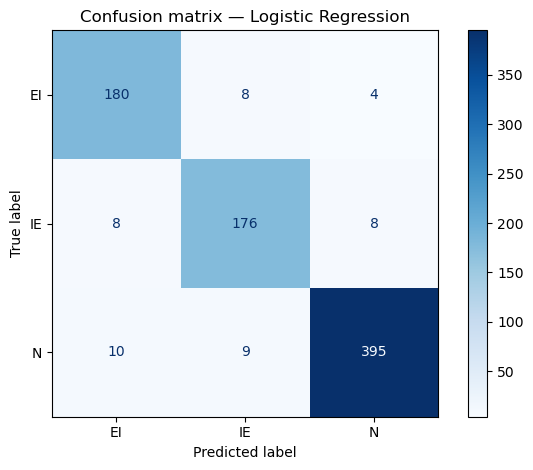

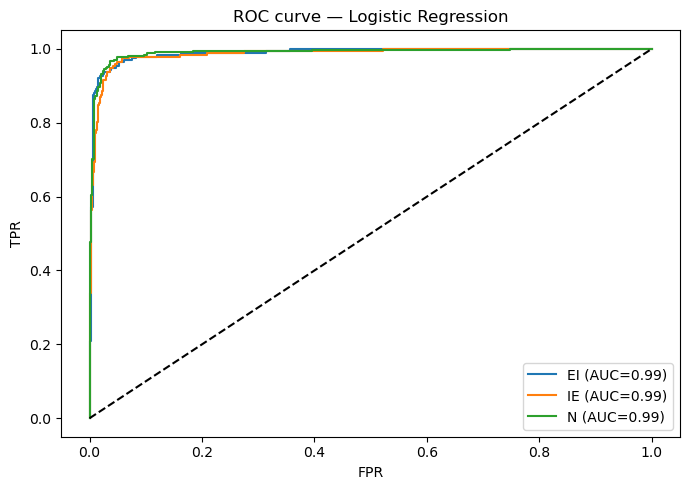

In [26]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_flat_train, y_train)

y_pred_lr = lr.predict(X_flat_test)
y_prob_lr = lr.predict_proba(X_flat_test)

evaluate_model("Logistic Regression", y_test, y_pred_lr, le.classes_, y_prob_lr)

### **6.2 MLP**

In [27]:
# Model architecture
mlp = keras.Sequential([
    keras.layers.Input(shape=(240,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

# Compilation
mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        30,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,299 (153.51 KB)

 Trainable params: 39,299 (153.51 KB)

 Non-trainable params: 0 (0.00 B)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step

  MLP
              precision    recall  f1-score   support

          EI       0.93      0.95      0.94       192
          IE       0.91      0.94      0.93       192
           N       0.98      0.96      0.97       414

    accuracy                           0.95       798
   macro avg       0.94      0.95      0.95       798
weighted avg       0.95      0.95      0.95       798



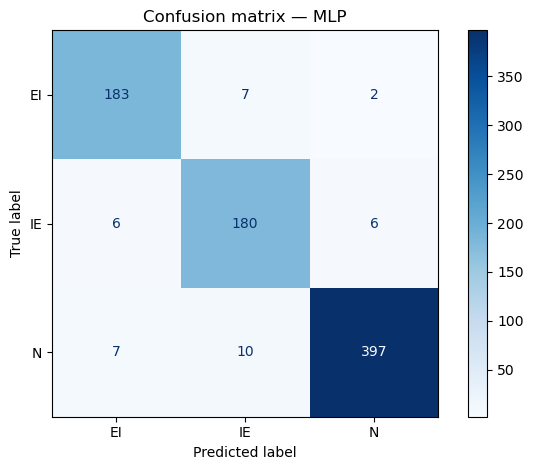

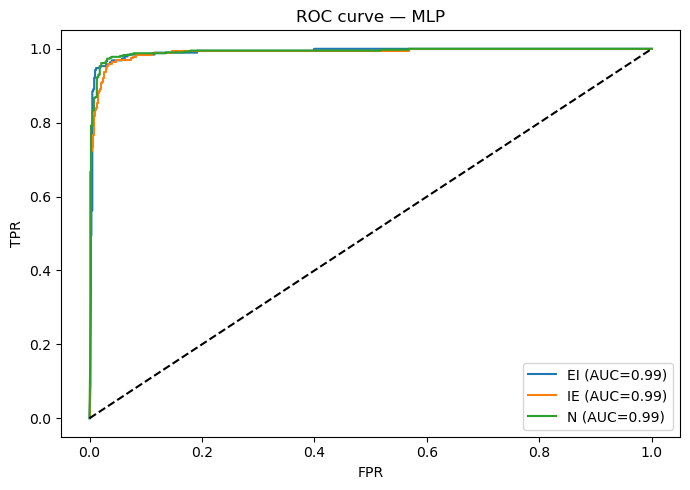

In [28]:
history_mlp = mlp.fit(
    X_flat_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

y_pred_mlp = np.argmax(mlp.predict(X_flat_test), axis=1)
y_prob_mlp = mlp.predict(X_flat_test)

evaluate_model("MLP", y_test, y_pred_mlp, le.classes_, y_prob_mlp)

Note that the **MLP** network has **17,603** parameters in total, all of which are adjusted during training via **backpropagation**. In contrast, the **Logistic Regression** model uses only **240 x 3 = 720** weights (in addition to the biases). As a first approximation, considering only the parametric capacity of the model, it is reasonable to expect that the **MLP** will exhibit better performance.

On the other hand, the main advantage of the **MLP** is not limited to the number of parameters, but rather to the fact that it incorporates **nonlinear activation layers**. These activations allow the network to learn **nonlinear relationships between features**, making it possible to capture more complex patterns present in biological sequences.

### **6.3 CNN 1D**

In [29]:
cnn = keras.Sequential([
    keras.layers.Input(shape=(60, 4)),                           # 60 nucleotídeos, 4 canais
    keras.layers.Conv1D(32, kernel_size=8, activation="relu"),   # detecta motifs de ~8bp
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(64, kernel_size=4, activation="relu"),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(3, activation="softmax")
], name="CNN_1D")

cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn.summary()

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 53, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 23, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,627 (213.39 KB)

 Trainable params: 54,627 (213.39 KB)

 Non-trainable params: 0 (0.00 B)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step

  CNN 1D
              precision    recall  f1-score   support

          EI       0.94      0.96      0.95       192
          IE       0.93      0.95      0.94       192
           N       0.98      0.96      0.97       414

    accuracy                           0.96       798
   macro avg       0.95      0.96      0.95       798
weighted avg       0.96      0.96      0.96       798



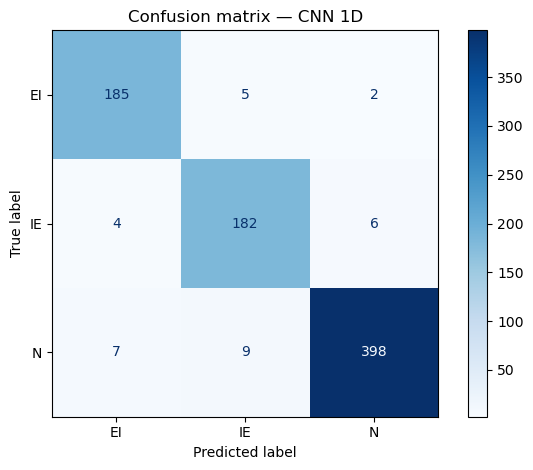

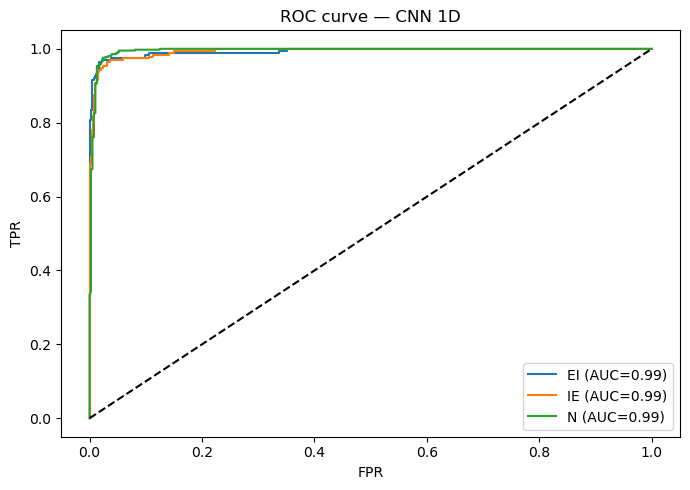

In [30]:
history_cnn = cnn.fit(
    X_cnn_train, 
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

y_pred_cnn = np.argmax(cnn.predict(X_cnn_test), axis=1)
y_prob_cnn = cnn.predict(X_cnn_test)

evaluate_model("CNN 1D", y_test, y_pred_cnn, le.classes_, y_prob_cnn)

## **7. Selecting the best model**

,Model,Accuracy,F1 Macro
0,Logistic Regression,0.941103,0.933201
1,MLP,0.952381,0.946075
2,CNN 1D,0.958647,0.954161


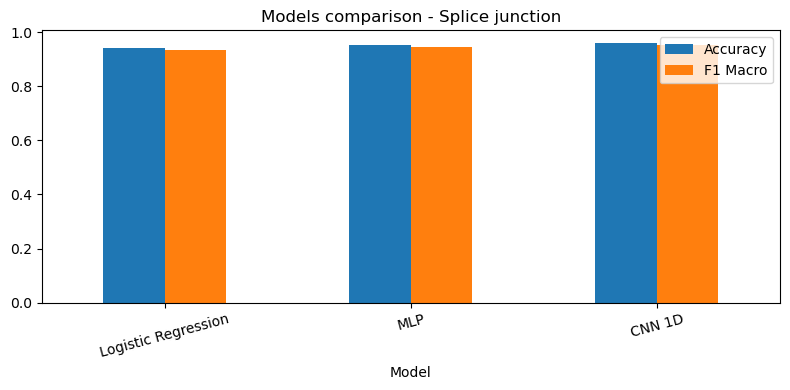

In [31]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP", "CNN 1D"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_cnn)
    ],
    "F1 Macro": [
        f1_score(y_test, y_pred_lr, average="macro"),
        f1_score(y_test, y_pred_mlp, average="macro"),
        f1_score(y_test, y_pred_cnn, average="macro")

    ]
})

display(results)

results.set_index("Model").plot(kind="bar", figsize=(8, 4), rot=15)
plt.title("Models comparison - Splice junction")
plt.tight_layout()
plt.show()

As expected, the CNN-1D shows the best performance, once the task of identifying local patterns on nitrogenous basis is very suitable to convolutional neural networks.